In [129]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

from sklearn.impute import SimpleImputer

In [131]:
import os

# 1. Point this to the actual folder where your project/notebook lives
os.chdir(r"C:\Users\khana\OneDrive\Desktop\ETA-Prediction") 

# 2. Verify it changed successfully
print("Current working directory:", os.getcwd())

Current working directory: C:\Users\khana\OneDrive\Desktop\ETA-Prediction


In [132]:
restaurants = pd.read_csv("dataset/restaurants.csv")

riders = pd.read_csv("dataset/riders.csv")

orders = pd.read_csv("dataset/orders.csv")

In [133]:
#for restaurants 
restaurants.head()
restaurants.tail()
restaurants.shape
restaurants.columns
restaurants.dtypes
restaurants.info()
restaurants.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4266 entries, 0 to 4265
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               4266 non-null   int64  
 1   name             4266 non-null   object 
 2   lat              4266 non-null   float64
 3   lon              4266 non-null   float64
 4   cuisine          4266 non-null   object 
 5   avg_rating       3923 non-null   float64
 6   prep_capacity    4266 non-null   int64  
 7   manager_contact  3677 non-null   object 
dtypes: float64(3), int64(2), object(3)
memory usage: 266.8+ KB


,id,name,lat,lon,cuisine,avg_rating,prep_capacity,manager_contact
count,4266.000000,4266,4266.000000,4266.000000,4266,3923.000000,4266.000000,3677
unique,NaN,225,NaN,NaN,10,NaN,NaN,3453
top,NaN,Urban Diner,NaN,NaN,Bakery & Desserts,NaN,NaN,+91-860561023
freq,NaN,35,NaN,NaN,478,NaN,NaN,3
mean,1994.763010,NaN,12.971632,77.594499,NaN,3.850217,13.892171,NaN
std,1152.680479,NaN,0.009290,0.009244,NaN,0.610065,24.816194,NaN
min,1.000000,NaN,12.955605,77.578604,NaN,2.800000,0.000000,NaN
25%,1003.250000,NaN,12.963633,77.586586,NaN,3.300000,6.000000,NaN
50%,1996.000000,NaN,12.971711,77.594409,NaN,3.800000,10.000000,NaN
75%,2988.750000,NaN,12.979662,77.602483,NaN,4.400000,15.000000,NaN


In [134]:
#for riders 
riders.head()
riders.tail()
riders.shape
riders.columns
riders.dtypes
riders.info()
riders.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6400 entries, 0 to 6399
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                6400 non-null   int64  
 1   lat               6400 non-null   float64
 2   lon               6400 non-null   float64
 3   vehicle_type      6160 non-null   object 
 4   completed_orders  6400 non-null   int64  
 5   shift_hours       6400 non-null   float64
 6   current_load      6400 non-null   int64  
 7   rider_call_sign   5795 non-null   object 
dtypes: float64(3), int64(3), object(2)
memory usage: 400.1+ KB


,id,lat,lon,vehicle_type,completed_orders,shift_hours,current_load,rider_call_sign
count,6400.000000,6400.000000,6400.000000,6160,6400.000000,6400.000000,6400.00000,5795
unique,NaN,NaN,NaN,14,NaN,NaN,NaN,5407
top,NaN,NaN,NaN,cycle,NaN,NaN,NaN,QQ-695
freq,NaN,NaN,NaN,521,NaN,NaN,NaN,4
mean,2995.832656,12.728542,76.139737,NaN,846.032969,5.612313,1.43375,NaN
std,1733.755724,1.759676,10.525830,NaN,1145.604288,3.428543,1.38642,NaN
min,1.000000,0.000000,0.000000,NaN,0.000000,0.000000,-1.00000,NaN
25%,1496.750000,12.961017,77.584026,NaN,38.000000,2.700000,0.00000,NaN
50%,2996.500000,12.971534,77.594195,NaN,289.000000,5.500000,1.00000,NaN
75%,4495.250000,12.981763,77.604680,NaN,1344.250000,8.300000,2.00000,NaN


In [135]:
#for orders 
orders.head()
orders.tail()
orders.shape
orders.columns
orders.dtypes
orders.info()
orders.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307500 entries, 0 to 307499
Data columns (total 12 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   id                        307500 non-null  int64  
 1   restaurant_id             307500 non-null  int64  
 2   rider_id                  294728 non-null  float64
 3   drop_lat                  301407 non-null  float64
 4   drop_lon                  301407 non-null  float64
 5   order_size                307500 non-null  int64  
 6   order_value               307500 non-null  float64
 7   timestamp                 307500 non-null  object 
 8   promised_eta              291823 non-null  float64
 9   actual_delivery_time_min  280427 non-null  float64
 10  order_status              307500 non-null  object 
 11  promo_code_used           153239 non-null  object 
dtypes: float64(6), int64(3), object(3)
memory usage: 28.2+ MB


,id,restaurant_id,rider_id,drop_lat,drop_lon,order_size,order_value,timestamp,promised_eta,actual_delivery_time_min,order_status,promo_code_used
count,307500.000000,307500.000000,294728.000000,301407.000000,301407.000000,307500.000000,307500.000000,307500,291823.000000,280427.000000,307500,153239
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,261694,NaN,NaN,2,3
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22/06/2026 20:19,NaN,NaN,delivered,BLR10
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,12,NaN,NaN,286192,51334
mean,150048.045197,2132.639418,2997.330824,12.995392,77.576013,2.922777,443.974843,NaN,29.946423,35.879625,NaN,NaN
std,86603.414045,1595.987164,1732.402487,0.380041,0.296663,1.815868,319.745645,NaN,139.129701,172.730246,NaN,NaN
min,1.000000,1.000000,1.000000,12.949600,72.701678,0.000000,-1756.960000,NaN,10.000000,8.000000,NaN,NaN
25%,75050.750000,1018.000000,1503.000000,12.960600,77.583488,1.000000,211.070000,NaN,15.000000,19.200000,NaN,NaN
50%,150093.500000,2029.000000,3000.000000,12.971651,77.594509,2.000000,376.330000,NaN,20.000000,24.400000,NaN,NaN
75%,225047.250000,3038.000000,4494.000000,12.982729,77.605540,4.000000,610.190000,NaN,25.000000,30.600000,NaN,NaN


In [136]:
restaurants.isnull().sum()

id                   0
name                 0
lat                  0
lon                  0
cuisine              0
avg_rating         343
prep_capacity        0
manager_contact    589
dtype: int64

In [137]:
(restaurants.isnull().sum()/len(restaurants))*100

id                  0.000000
name                0.000000
lat                 0.000000
lon                 0.000000
cuisine             0.000000
avg_rating          8.040319
prep_capacity       0.000000
manager_contact    13.806845
dtype: float64

In [138]:
orders.isnull().sum()

id                               0
restaurant_id                    0
rider_id                     12772
drop_lat                      6093
drop_lon                      6093
order_size                       0
order_value                      0
timestamp                        0
promised_eta                 15677
actual_delivery_time_min     27073
order_status                     0
promo_code_used             154261
dtype: int64

In [139]:
(orders.isnull().sum()/len(orders))*100

id                           0.000000
restaurant_id                0.000000
rider_id                     4.153496
drop_lat                     1.981463
drop_lon                     1.981463
order_size                   0.000000
order_value                  0.000000
timestamp                    0.000000
promised_eta                 5.098211
actual_delivery_time_min     8.804228
order_status                 0.000000
promo_code_used             50.166179
dtype: float64

In [140]:
riders.isnull().sum()

id                    0
lat                   0
lon                   0
vehicle_type        240
completed_orders      0
shift_hours           0
current_load          0
rider_call_sign     605
dtype: int64

In [141]:
(riders.isnull().sum()/len(riders))*100

id                  0.000000
lat                 0.000000
lon                 0.000000
vehicle_type        3.750000
completed_orders    0.000000
shift_hours         0.000000
current_load        0.000000
rider_call_sign     9.453125
dtype: float64

In [142]:
print(orders.duplicated().sum())       
print(restaurants.duplicated().sum())  
print(riders.duplicated().sum())     

7500
266
400


In [143]:
orders.drop_duplicates(inplace=True)
restaurants.drop_duplicates(inplace=True)
riders.drop_duplicates(inplace=True)

In [144]:
print(orders.duplicated().sum())       
print(restaurants.duplicated().sum())  
print(riders.duplicated().sum())     

0
0
0


In [145]:
print(riders["vehicle_type"].value_counts())

vehicle_type
cycle          494
scooter        486
Scooter        481
e-scooter      471
bicycle        470
Bicycle        449
CAR            381
Car            380
BIKE           366
Bike           365
4-wheeler      364
car            359
bike           356
two_wheeler    354
Name: count, dtype: int64


In [146]:
riders["vehicle_type"] = riders["vehicle_type"].str.lower().str.strip()

In [147]:
def normalise_vehicle(v):
    """Casing alone isn't enough -- two_wheeler/4-wheeler/cycle/e-scooter
    are synonyms, not casing variants, and need explicit mapping."""
    if pd.isna(v):
        return "bike"
    v = str(v).strip()
    if v in ("bike", "two_wheeler", "scooter", "e-scooter"):
        return "bike"
    if v in ("bicycle", "cycle"):
        return "bicycle"
    if v in ("car", "4-wheeler"):
        return "car"
    return "bike"

riders["vehicle_type"] = riders["vehicle_type"].apply(normalise_vehicle)
print(riders["vehicle_type"].value_counts())

vehicle_type
bike       3103
car        1484
bicycle    1413
Name: count, dtype: int64


In [148]:
orders[~orders["restaurant_id"].isin(restaurants["id"])].count()

id                          4545
restaurant_id               4545
rider_id                    4348
drop_lat                    4456
drop_lon                    4456
order_size                  4545
order_value                 4545
timestamp                   4545
promised_eta                4301
actual_delivery_time_min    4140
order_status                4545
promo_code_used             2197
dtype: int64

In [149]:
orders[~orders["restaurant_id"].isin(restaurants["id"])]  
orders[~orders["rider_id"].isin(riders["id"])]            

,id,restaurant_id,rider_id,drop_lat,drop_lon,order_size,order_value,timestamp,promised_eta,actual_delivery_time_min,order_status,promo_code_used
11,12,2895,NaN,12.949704,77.615568,3,597.40,03/05/2026 13:23,30.0,NaN,cancelled,BLR10
30,31,2817,NaN,12.953563,77.586152,3,535.19,1777663004,25.0,NaN,cancelled,BLR10
57,58,2489,NaN,12.985467,77.594329,1,223.05,2026-05-04 20:41:04,10.0,NaN,cancelled,NaN
62,63,1908,NaN,12.962414,77.597652,4,402.49,2026-05-30 14:43:24,15.0,NaN,cancelled,NaN
63,64,2577,NaN,12.962946,77.609491,2,254.49,2026-06-17 21:05:03,35.0,NaN,cancelled,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
299892,299893,823,NaN,12.967992,77.586576,1,118.10,2026-05-24 21:36:43,15.0,NaN,cancelled,NaN
299945,299946,1318,NaN,12.970062,77.581145,5,649.02,2026-05-21 13:00:29,25.0,NaN,cancelled,NaN
299949,299950,53,NaN,12.989252,77.594069,8,1431.49,2026-06-19 18:16:14,NaN,NaN,cancelled,NaN
299973,299974,3940,NaN,12.982829,77.616600,2,283.91,31/05/2026 20:49,35.0,NaN,cancelled,NaN


In [150]:
restaurants[(restaurants.lat < 8) | (restaurants.lat > 37)]   # 0 rows
riders[(riders.lat < 8) | (riders.lat > 37) | (riders.lon < 68) | (riders.lon > 97)]  # 112 rows

,id,lat,lon,vehicle_type,completed_orders,shift_hours,current_load,rider_call_sign
0,1,0.0,0.0,bike,12,6.0,1,TW-258
11,12,0.0,0.0,bicycle,251,9.9,0,JZ-805
79,80,0.0,0.0,bike,466,0.1,0,NV-462
156,157,0.0,0.0,bicycle,132,1.7,3,NL-737
171,172,0.0,0.0,bike,18,8.1,1,CV-690
...,...,...,...,...,...,...,...,...
5889,5890,0.0,0.0,bike,6,2.6,0,AB-210
5893,5894,0.0,0.0,bike,454,3.8,-1,BF-574
5927,5928,0.0,0.0,bike,818,1.7,2,NaN
5980,5981,0.0,0.0,bike,49,2.5,2,XH-613


In [151]:
mask = (riders.lat == 0) & (riders.lon == 0)
riders.loc[mask, ["lat", "lon"]] = np.nan

In [152]:

order_cols = ["order_value", "order_size", "actual_delivery_time_min"]
for col in order_cols:
    Q1 = orders[col].quantile(.25)
    Q3 = orders[col].quantile(.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_out = ((orders[col] < lower) | (orders[col] > upper)).sum()
    print(f"{col}: lower={lower}, upper={upper}, outliers={n_out}")

order_value: lower=-387.4337499999998, upper=1208.6562499999998, outliers=10290
order_size: lower=-3.5, upper=8.5, outliers=0
actual_delivery_time_min: lower=2.099999999999998, upper=47.7, outliers=6562


<Axes: xlabel='actual_delivery_time_min', ylabel='order_value'>

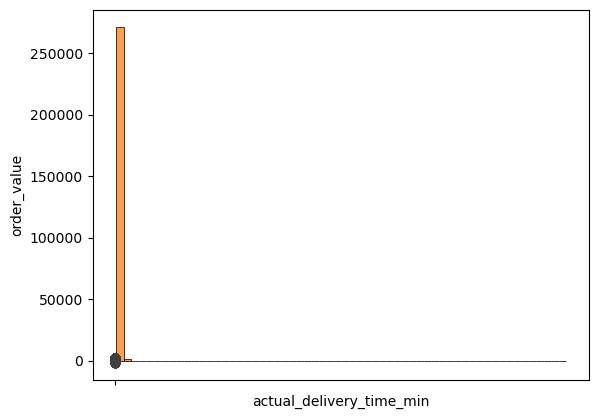

In [153]:
sns.boxplot(y=orders["order_value"])
sns.histplot(orders["actual_delivery_time_min"], bins=60)

In [154]:
is_epoch = orders["timestamp"].astype(str).str.fullmatch(r"\d{9,11}")

orders["timestamp"] = orders["timestamp"].astype(str)
parsed = pd.Series(index=orders.index, dtype="datetime64[ns]")
parsed.loc[~is_epoch] = pd.to_datetime(orders.loc[~is_epoch, "timestamp"], format="mixed", dayfirst=True)
parsed.loc[is_epoch] = pd.to_datetime(orders.loc[is_epoch, "timestamp"].astype(int), unit="s")
orders["timestamp"] = parsed

orders["hour"] = orders["timestamp"].dt.hour
orders["day"] = orders["timestamp"].dt.day
orders["month"] = orders["timestamp"].dt.month
orders["weekday"] = orders["timestamp"].dt.day_name()
orders["is_weekend"] = orders["timestamp"].dt.dayofweek >= 5

In [155]:
restaurants.drop(columns=["manager_contact"], inplace=True)
riders.drop(columns=["rider_call_sign"], inplace=True)
orders.drop(columns=["promo_code_used"], inplace=True)

In [156]:
merged = (
    orders
    .merge(restaurants, left_on="restaurant_id", right_on="id", suffixes=("", "_restaurant"))
    .merge(riders, left_on="rider_id", right_on="id", suffixes=("", "_rider"), how="left")
)

In [157]:
merged

,id,restaurant_id,rider_id,drop_lat,drop_lon,order_size,order_value,timestamp,promised_eta,actual_delivery_time_min,...,cuisine,avg_rating,prep_capacity,id_rider,lat_rider,lon_rider,vehicle_type,completed_orders,shift_hours,current_load
0,1,1921,5764.0,12.967183,77.601366,7,843.86,2026-05-06 19:22:36,15.0,22.2,...,Biryani,3.9,20,5764.0,12.972401,77.586219,bike,28.0,1.9,1.0
1,2,417,3377.0,12.985586,77.615225,1,156.37,2026-05-18 22:56:00,15.0,19.2,...,Italian,4.2,8,3377.0,12.984731,77.596576,bike,3768.0,9.9,1.0
2,3,692,3424.0,12.956571,77.608251,2,290.15,2026-06-05 19:20:00,20.0,20.1,...,North Indian,3.4,10,3424.0,12.956561,77.609717,car,2643.0,1.4,2.0
3,4,140,861.0,12.950077,77.590249,2,164.77,2026-05-16 19:39:57,20.0,18.6,...,Bakery & Desserts,4.5,12,861.0,12.984981,77.597929,car,1673.0,10.9,0.0
4,5,189,4881.0,12.972294,77.579577,2,384.46,2026-05-19 19:50:36,20.0,20.1,...,Biryani,4.6,15,4881.0,12.970247,77.581581,car,1.0,0.6,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
295450,299996,210,1395.0,12.970076,77.592430,3,433.29,2026-06-21 21:41:04,20.0,28.3,...,Continental,3.0,4,1395.0,12.977361,77.609596,bike,3393.0,1.4,1.0
295451,299997,1504,994.0,12.985175,77.599272,6,746.10,2026-05-01 15:29:18,30.0,41.6,...,Bakery & Desserts,3.0,10,994.0,12.979247,77.579928,bike,313.0,10.4,0.0
295452,299998,752,2508.0,12.982762,77.606369,2,249.56,2026-05-24 21:47:00,20.0,20.6,...,Beverages,NaN,4,2508.0,12.969612,77.597041,bike,172.0,18.3,0.0
295453,299999,1139,3109.0,12.951319,77.595881,2,268.77,2026-06-03 19:14:22,20.0,18.7,...,Beverages,4.4,6,3109.0,12.983208,77.589139,car,354.0,2.3,0.0


In [158]:

before = len(merged)
p995 = merged["actual_delivery_time_min"].quantile(0.995)
merged = merged[merged["actual_delivery_time_min"].between(8, p995)]
print(f"Target outlier cap applied: {before} -> {len(merged)} rows (cap = {p995:.1f} min)")

Target outlier cap applied: 295455 -> 268112 rows (cap = 108.2 min)


In [159]:
merged.to_csv("cleaned_data/cleaned_dataset.csv", index=False)

In [160]:
merged.shape


(268112, 30)

In [161]:
df = merged.copy()

actual_delivery_time_min    1.000000
promised_eta                0.770345
order_size                  0.333379
order_value                 0.277030
current_load                0.057410
hour                        0.033167
lon_rider                   0.009223
id_restaurant               0.005396
restaurant_id               0.005396
lat_rider                   0.005059
month                       0.003892
avg_rating                  0.003816
is_weekend                  0.003739
drop_lon                   -0.000280
drop_lat                   -0.000418
day                        -0.000558
id                         -0.003112
lon                        -0.004126
shift_hours                -0.005324
completed_orders           -0.005814
lat                        -0.007606
id_rider                   -0.016361
rider_id                   -0.016361
prep_capacity              -0.075306
Name: actual_delivery_time_min, dtype: float64


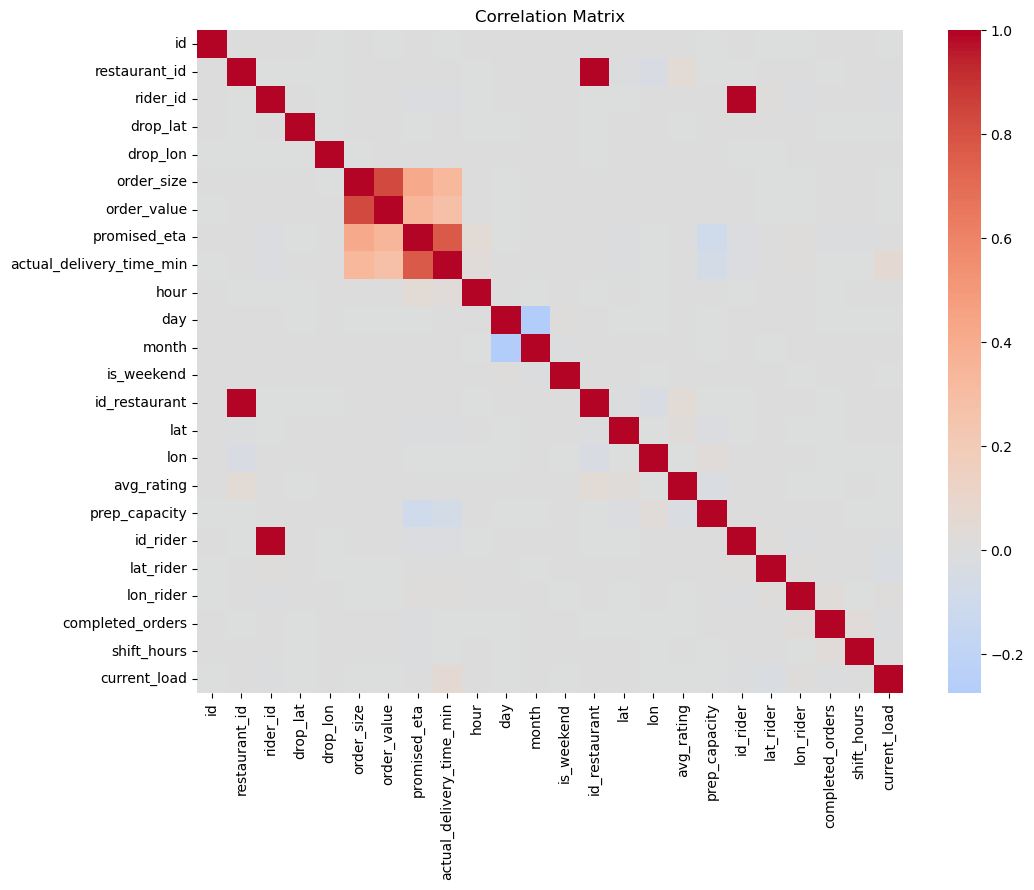

In [162]:
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("cleaned_data/cleaned_dataset.csv")

corr = df.corr(numeric_only=True)
print(corr["actual_delivery_time_min"].sort_values(ascending=False))

plt.figure(figsize=(11, 9))
sns.heatmap(corr, cmap="coolwarm", center=0, annot=False)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.savefig("cleaned_data/step17_correlation_heatmap.png", dpi=100)
plt.show()

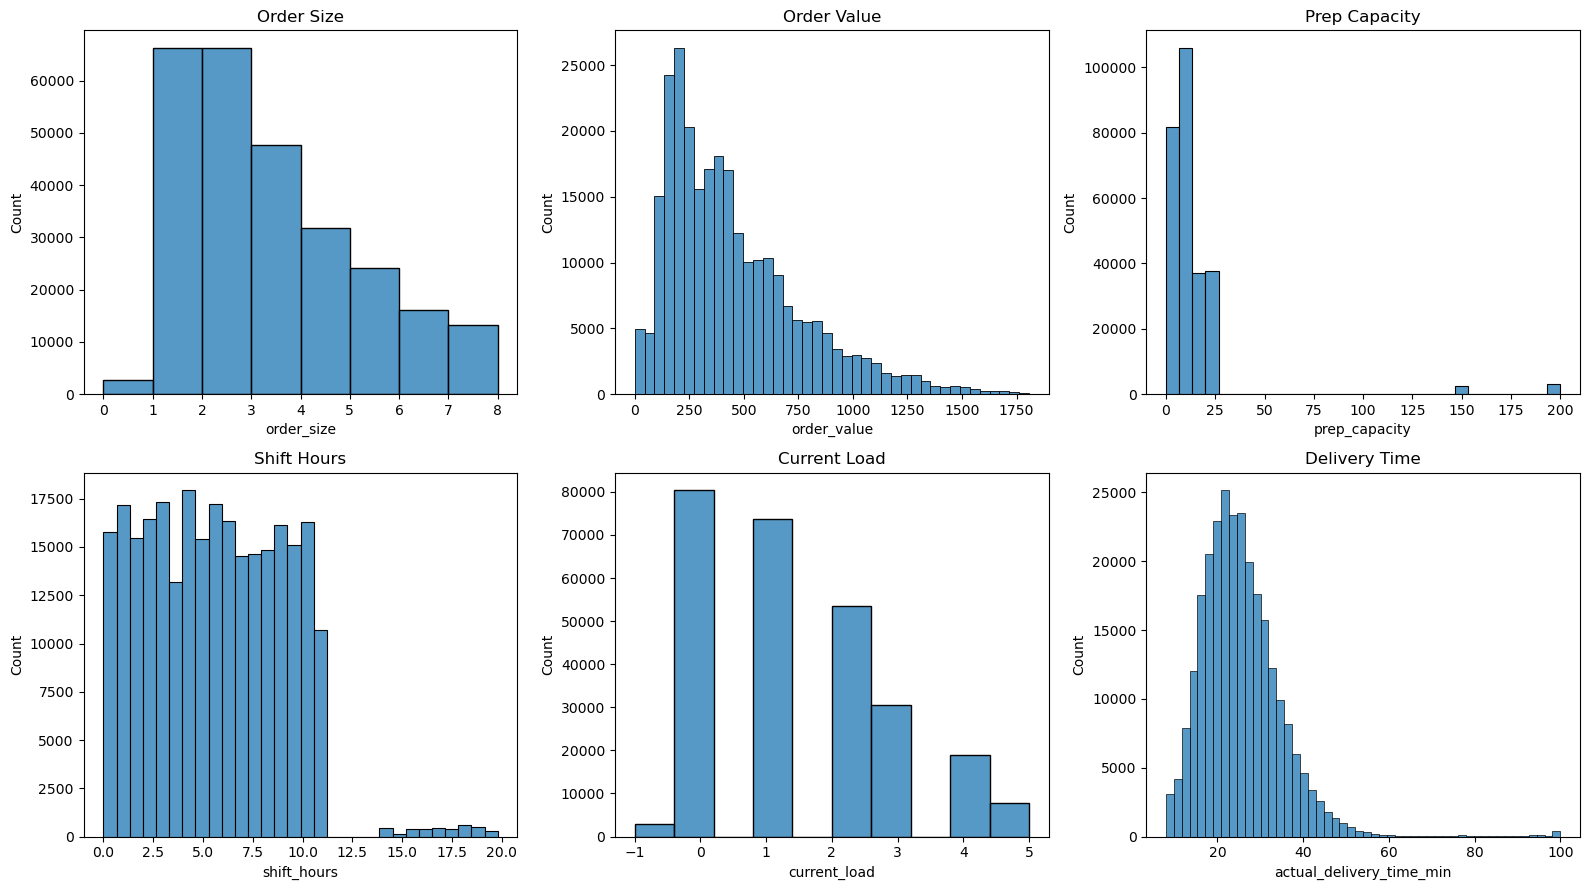

In [163]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

sns.histplot(df["order_size"], bins=8, ax=axes[0,0]); axes[0,0].set_title("Order Size")
sns.histplot(df["order_value"].clip(0, 2000), bins=40, ax=axes[0,1]); axes[0,1].set_title("Order Value")
sns.histplot(df["prep_capacity"], bins=30, ax=axes[0,2]); axes[0,2].set_title("Prep Capacity")
sns.histplot(df["shift_hours"], bins=30, ax=axes[1,0]); axes[1,0].set_title("Shift Hours")
sns.histplot(df["current_load"], bins=10, ax=axes[1,1]); axes[1,1].set_title("Current Load")
sns.histplot(df["actual_delivery_time_min"].clip(0, 100), bins=50, ax=axes[1,2]); axes[1,2].set_title("Delivery Time")

plt.tight_layout()
plt.savefig("cleaned_data/step18_distributions.png", dpi=100)
plt.show()

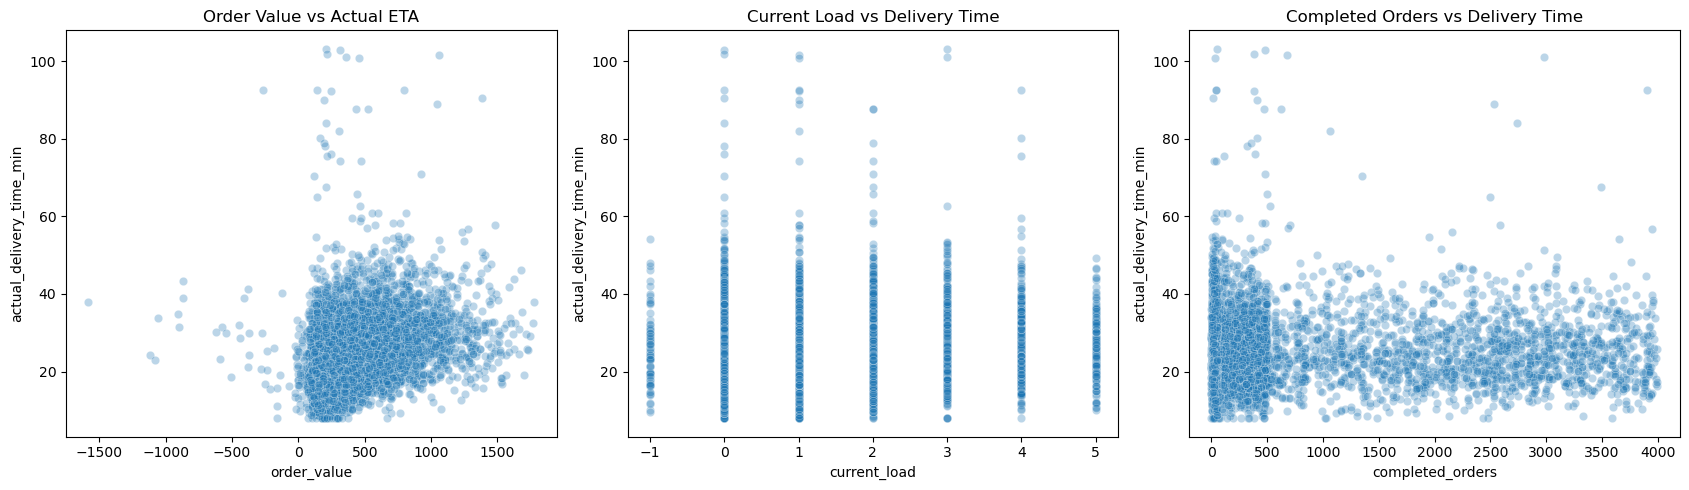

In [164]:
sample = df.dropna(subset=["actual_delivery_time_min"])
sample = sample[sample["actual_delivery_time_min"] <= 120].sample(5000, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

sns.scatterplot(x="order_value", y="actual_delivery_time_min", data=sample, alpha=0.3, ax=axes[0])
axes[0].set_title("Order Value vs Actual ETA")

sns.scatterplot(x="current_load", y="actual_delivery_time_min", data=sample, alpha=0.3, ax=axes[1])
axes[1].set_title("Current Load vs Delivery Time")

sns.scatterplot(x="completed_orders", y="actual_delivery_time_min", data=sample, alpha=0.3, ax=axes[2])
axes[2].set_title("Completed Orders vs Delivery Time")

plt.tight_layout()
plt.savefig("cleaned_data/step19_scatterplots.png", dpi=100)
plt.show()

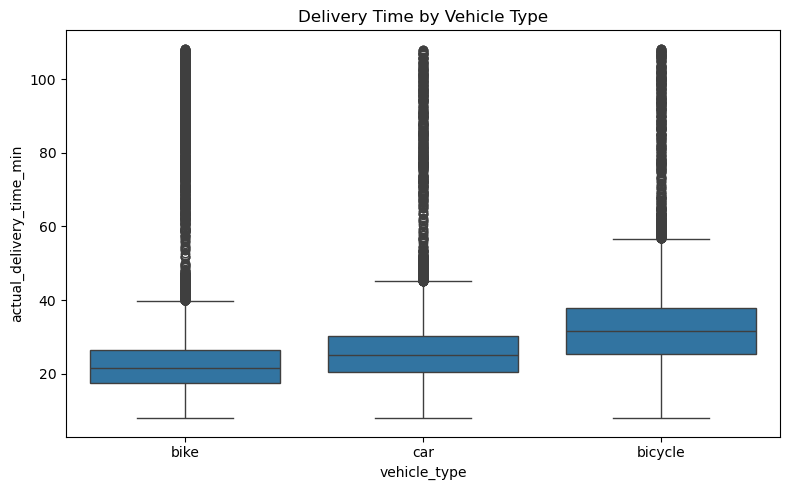

                   mean  median        std   count
vehicle_type                                      
bicycle       32.253910    31.5  10.064551   62996
bike          22.460201    21.6   8.424922  138959
car           25.919691    25.2   8.661308   66157


In [165]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="vehicle_type", y="actual_delivery_time_min",
            data=df[df["actual_delivery_time_min"] <= 120])
plt.title("Delivery Time by Vehicle Type")
plt.tight_layout()
plt.savefig("cleaned_data/step20_vehicle_boxplot.png", dpi=100)
plt.show()

print(df.groupby("vehicle_type")["actual_delivery_time_min"].agg(["mean", "median", "std", "count"]))

cuisine
Fast Food            25.850646
Healthy Bowls        25.674687
Bakery & Desserts    25.653078
Beverages            25.647051
North Indian         25.634179
South Indian         25.570695
Continental          25.551661
Chinese              25.550463
Biryani              25.534234
Italian              25.486183
Name: actual_delivery_time_min, dtype: float64


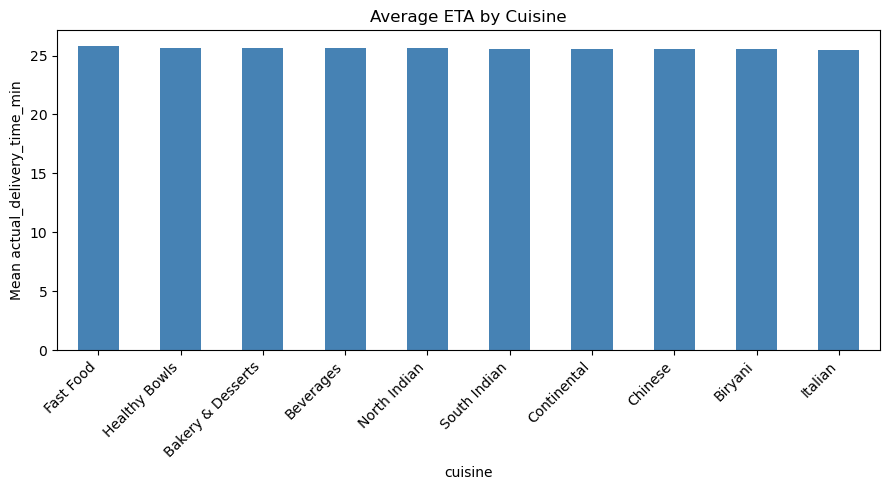

In [166]:
avg_by_cuisine = df.groupby("cuisine")["actual_delivery_time_min"].mean().sort_values(ascending=False)
print(avg_by_cuisine)

plt.figure(figsize=(9, 5))
avg_by_cuisine.plot(kind="bar", color="steelblue")
plt.title("Average ETA by Cuisine")
plt.ylabel("Mean actual_delivery_time_min")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("cleaned_data/step21_cuisine_bar.png", dpi=100)
plt.show()

hour
7     24.198772
8     24.047040
9     24.063038
10    24.136190
11    24.123589
12    26.365307
13    26.281828
14    24.004407
15    24.090276
16    23.765359
17    23.881887
18    23.970591
19    26.307883
20    26.366876
21    26.328810
22    24.299055
23    24.290631
Name: actual_delivery_time_min, dtype: float64


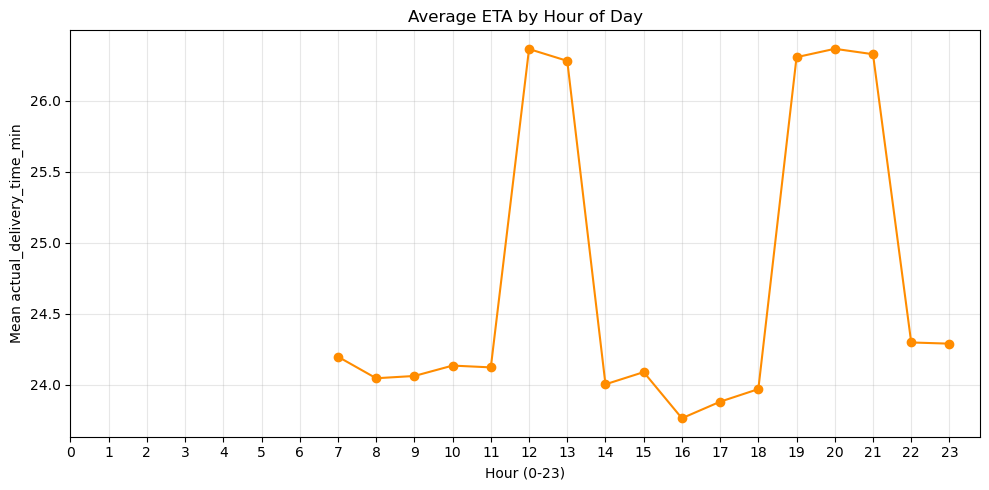

In [167]:
avg_by_hour = df.groupby("hour")["actual_delivery_time_min"].mean()
print(avg_by_hour)

plt.figure(figsize=(10, 5))
avg_by_hour.plot(kind="line", marker="o", color="darkorange")
plt.title("Average ETA by Hour of Day")
plt.xlabel("Hour (0-23)")
plt.ylabel("Mean actual_delivery_time_min")
plt.xticks(range(0, 24))
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("cleaned_data/step22_hourly_eta.png", dpi=100)
plt.show()